In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

from qae import QAEConfig, QuantumAutoencoder
from preprocessing import timed_preprocess

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, Sampler

service = QiskitRuntimeService(
    channel="ibm_cloud", 
    token="token", 
    instance="crn"
)

backend = service.backend("ibm_kingston")

In [27]:
prep = timed_preprocess(percent10=True, n_components=4, vis_samples=1000)

X_train = prep["X_train_pca"]
X_test = prep["X_test_pca"]
y_train = prep["y_train"]
y_test = prep["y_test"]

print("Full train:", X_train.shape)
print("Full test: ", X_test.shape)

Preprocessing time: 12.21s
Full train: (155644, 4)
Full test:  (98805, 4)


In [ ]:
X_train_qae_full, X_val_qae, y_train_qae_full, y_val_qae = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

rng = np.random.default_rng(42)

train_subset_size = 6000 
train_idx = rng.choice(len(X_train_qae_full), size=train_subset_size, replace=False)
X_train_qae = X_train_qae_full[train_idx]
y_train_qae = y_train_qae_full[train_idx]

val_subset_size = 650 
val_idx = rng.choice(len(X_val_qae), size=val_subset_size, replace=False)
X_val_qae_small = X_val_qae[val_idx]
y_val_qae_small = y_val_qae[val_idx]

print("QAE train subset:", X_train_qae.shape)
print("QAE val subset:  ", X_val_qae_small.shape)

QAE train subset: (6000, 4)
QAE val subset:   (650, 4)


In [ ]:
config = QAEConfig(
    n_qubits=4,
    n_latent=2,
    n_layers=1,
    device_name="default.qubit",
    seed=42,
    use_swap_test_loss=True,
    use_log_cost=True,
)

qae = QuantumAutoencoder(config)

best_params, history, scaler = qae.train(
    X_train_raw=X_train_qae,
    X_val_raw=X_val_qae_small,
    steps=80,  
    lr=0.03,
    batch_size=32, 
    val_every=10, 
    verbose=True,
)

[Step 000] train_loss=-0.145103 | val_loss=-0.170801
[Step 005] train_loss=-0.191523
[Step 010] train_loss=-0.256723 | val_loss=-0.251975
[Step 015] train_loss=-0.339492
[Step 020] train_loss=-0.308618 | val_loss=-0.338886
[Step 025] train_loss=-0.337087
[Step 030] train_loss=-0.473075 | val_loss=-0.393989
[Step 035] train_loss=-0.338344
[Step 040] train_loss=-0.434210 | val_loss=-0.403045
[Step 045] train_loss=-0.438847
[Step 050] train_loss=-0.274667 | val_loss=-0.405578
[Step 055] train_loss=-0.463461
[Step 060] train_loss=-0.391426 | val_loss=-0.409297
[Step 065] train_loss=-0.470605
[Step 070] train_loss=-0.501189 | val_loss=-0.409764
[Step 075] train_loss=-0.445320
[Step 079] train_loss=-0.400680 | val_loss=-0.410356


In [30]:
qae.save_checkpoint(
    "qae_checkpoint.npz",
    params=best_params,
    scaler=scaler,
    history=history,
    extra_metadata={"dataset": "KDDCup99 PCA-4"}
)

In [31]:
qknn_train_size = 2000
qknn_test_size = 400

train_idx_small = rng.choice(len(X_train), size=qknn_train_size, replace=False)
test_idx_small = rng.choice(len(X_test), size=qknn_test_size, replace=False)

X_train_small = X_train[train_idx_small]
y_train_small = y_train[train_idx_small]

X_test_small = X_test[test_idx_small]
y_test_small = y_test[test_idx_small]

In [ ]:
import pennylane as qml
from pennylane import numpy as np

def apply_trained_encoder(params, wires, n_layers):
    """Apply the trained QAE encoder circuit on specific wires."""
    n_qubits = len(wires)
    
    for layer in range(n_layers):
        for i, w in enumerate(wires):
            qml.RY(params[layer, i, 0], wires=w)
            qml.RZ(params[layer, i, 1], wires=w)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[wires[i], wires[i + 1]])
        qml.CNOT(wires=[wires[-1], wires[0]])

In [ ]:
import json
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

def build_qknn_swap_test(qae_inst, dev):
    n_q = qae_inst.config.n_qubits
    n_latent = qae_inst.config.n_latent

    @qml.qnode(dev)
    def circuit(x1, x2, params):
        ancilla = 0
        reg1 = list(range(1, n_q + 1))
        reg2 = list(range(n_q + 1, 2 * n_q + 1))

        # Encode + apply trained encoder (REGISTER 1)
        qml.AngleEmbedding(x1, wires=reg1, rotation="Y")
        apply_trained_encoder(params, reg1, qae_inst.config.n_layers)

        # Encode + apply trained encoder (REGISTER 2)
        qml.AngleEmbedding(x2, wires=reg2, rotation="Y")
        apply_trained_encoder(params, reg2, qae_inst.config.n_layers)

        # swap test
        qml.Hadamard(wires=ancilla)
        for i in range(n_latent):
            qml.CSWAP(wires=[ancilla, reg1[i], reg2[i]])
        qml.Hadamard(wires=ancilla)

        return qml.probs(wires=[ancilla])

    return circuit

In [ ]:
def compute_fidelity_matrix(qnode, X_test, X_train, params):
    n_test = len(X_test)
    n_train = len(X_train)

    fidelities = np.zeros((n_test, n_train))

    for i in range(n_test):
        xt = X_test[i]
        for j in range(n_train):
            probs = qnode(xt, X_train[j], params)
            fidelities[i, j] = np.clip(2 * probs[0] - 1, 0.0, 1.0)

        if (i + 1) % 20 == 0:
            print(f"Processed {i+1}/{n_test}")

    return fidelities

In [35]:
from collections import Counter
def qknn_predict(fidelity_matrix, y_train, k=3):
    y_pred = []
    y_prob = []

    for row in fidelity_matrix:
        idx = np.argsort(row)[-k:]
        labels = y_train[idx]

        y_pred.append(Counter(labels).most_common(1)[0][0])
        y_prob.append(np.mean(labels))

    return np.array(y_pred), np.array(y_prob)

In [ ]:
qknn_test_n = 7
qknn_train_n = 12

X_te_angles = qae.transform_to_angles(X_test_small[:qknn_test_n], scaler)
X_tr_angles = qae.transform_to_angles(X_train_small[:qknn_train_n], scaler)

y_tr_labels = y_train_small[:qknn_train_n]
y_te_true = y_test_small[:qknn_test_n]

pairs = [(xt, xr) for xt in X_te_angles for xr in X_tr_angles]

n_test = len(X_te_angles)
n_train = len(X_tr_angles)

print(f"Total circuits to run: {len(pairs)}")

with Batch(backend=backend) as batch:
    dev_ibm = qml.device("qiskit.remote", 
                         wires=1 + (2 * qae.config.n_qubits), 
                         backend=backend, 
                         shots=2048)
    
    qknn_qnode_ibm = build_qknn_swap_test(qae, dev_ibm)
    probs_list = [qknn_qnode_ibm(xt, xr, best_params) for (xt, xr) in pairs]
F = np.zeros((qknn_test_n, qknn_train_n))

for idx, probs in enumerate(probs_list):
    fidelity = np.clip(2 * probs[0] - 1, 0.0, 1.0)
    i = idx // qknn_train_n
    j = idx % qknn_train_n
    F[i, j] = fidelity


# --- PREDICT ---
y_pred_qknn, y_prob_qknn = qknn_predict(F, y_tr_labels, k=3)

Total circuits to run: 84


/Users/nicoletadobrica/AQA_QDL/.venv/lib/python3.13/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
base_primitive._get_mode_service_backend:WARNING:2026-04-06 00:52:49,595: A backend was passed in as the mode but a session context manager is open so this job will run inside this session/batch instead of in job mode.
base_primitive._get_mode_service_backend:WARNING:2026-04-06 00:52:57,891: A backend was passed in as the mode but a session context manager is open so this job will run inside this session/batch instead of in job mode.
base_primitive._get_mode_service_backend:WARNING:2026-04-06 00:53:05,538: A backend was passed in as the mode but a session context manager is open so this job will run inside this session/batch instead of in job mode.
base_primitive._get_mode_service_backend:WARNING:2026-04-06 00:53:13,331: A backend w

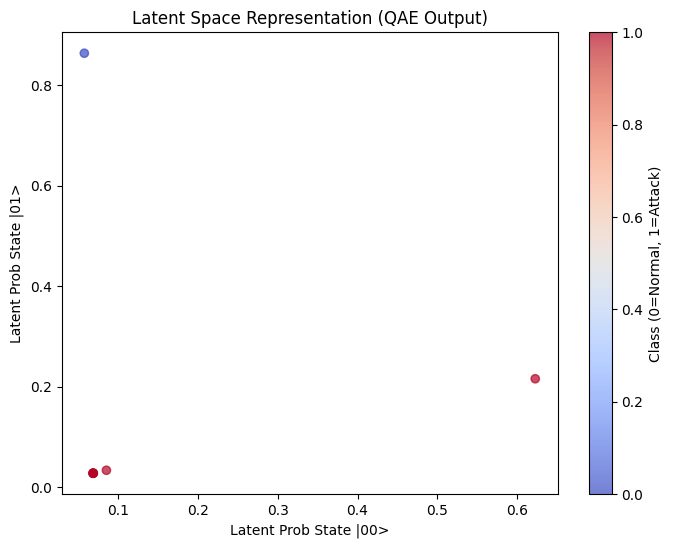

In [ ]:
import matplotlib.pyplot as plt

def get_latent_features(qae_model, X_angles, params):
    """Extracts the probability distribution of the latent qubits."""
    n_q = qae_model.config.n_qubits
    n_latent = qae_model.config.n_latent
    
    dev_latent = qml.device("default.qubit", wires=n_q)
    
    @qml.qnode(dev_latent)
    def latent_circuit(x):
        qml.AngleEmbedding(x, wires=range(n_q), rotation="Y")
        apply_trained_encoder(params, range(n_q), qae_model.config.n_layers)
        return qml.probs(wires=range(n_latent))

    latent_reps = np.array([latent_circuit(x) for x in X_angles])
    return latent_reps

latent_features = get_latent_features(qae, X_te_angles, best_params)
plt.figure(figsize=(8, 6))
plt.scatter(latent_features[:, 0], latent_features[:, 1], c=y_te_true, cmap='coolwarm', alpha=0.7)
plt.title("Latent Space Representation (QAE Output)")
plt.xlabel("Latent Prob State |00>")
plt.ylabel("Latent Prob State |01>")
plt.colorbar(label="Class (0=Normal, 1=Attack)")
plt.show()


Accuracy: 0.8571 | ROC-AUC: 1.0000


,precision,recall,f1-score,support
normal,0.5000,1.0000,0.6667,1.0000
attack,1.0000,0.8333,0.9091,6.0000
accuracy,0.8571,0.8571,0.8571,0.8571
macro avg,0.7500,0.9167,0.7879,7.0000
weighted avg,0.9286,0.8571,0.8745,7.0000


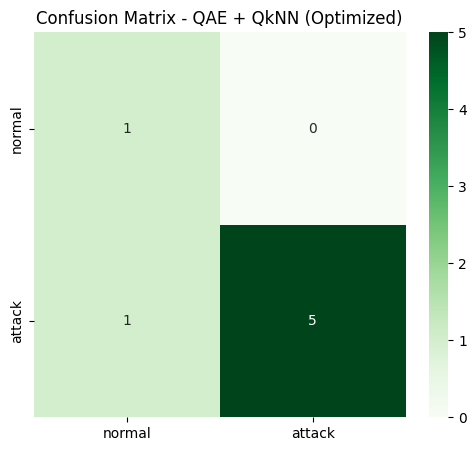

Extracting latent clusters for visualization...


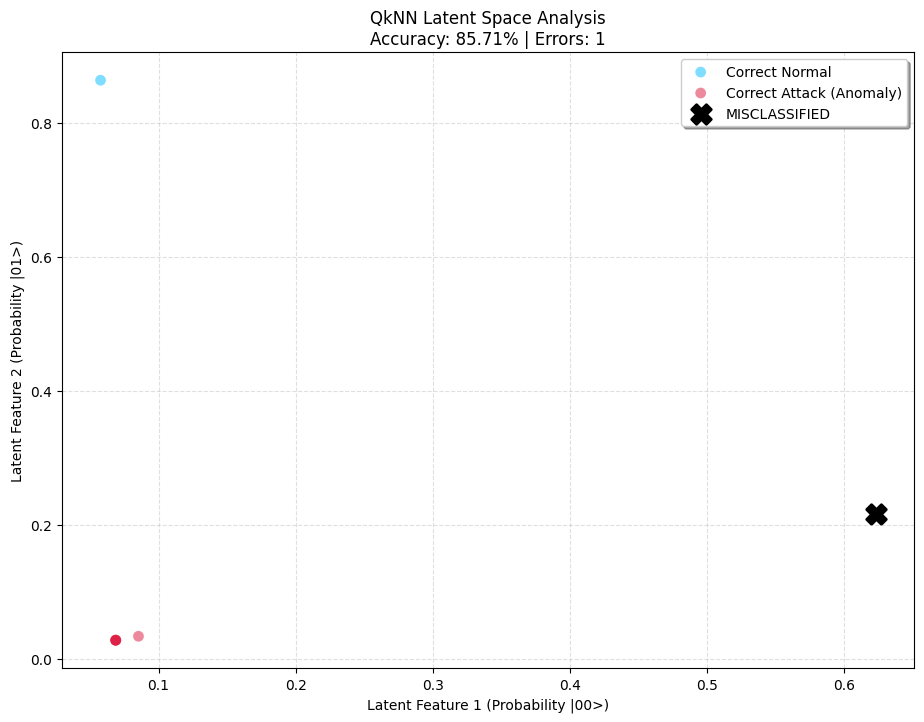

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)

y_te_true_int = np.array(y_te_true, dtype=int)
y_pred_qknn_int = np.array(y_pred_qknn, dtype=int)

acc_qknn = accuracy_score(y_te_true_int, y_pred_qknn_int)
auc_qknn = roc_auc_score(y_te_true_int, y_prob_qknn)
cm_qknn = confusion_matrix(y_te_true_int, y_pred_qknn_int)

report_qknn = pd.DataFrame(classification_report(
    y_te_true_int,
    y_pred_qknn_int,
    target_names=["normal", "attack"],
    output_dict=True
)).T

print(f"\nAccuracy: {acc_qknn:.4f} | ROC-AUC: {auc_qknn:.4f}")
display(report_qknn.round(4))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_qknn, annot=True, fmt="d", cmap="Greens",
            xticklabels=["normal", "attack"],
            yticklabels=["normal", "attack"])
plt.title("Confusion Matrix - QAE + QkNN (Optimized)")
plt.show()


def visualize_qknn_results(qae_inst, X_angles, y_true, y_pred, params):
    """
    Plots the 2D Latent Clusters.
    """
    n_q = qae_inst.config.n_qubits
    n_lat = qae_inst.config.n_latent
    dev_latent = qml.device("default.qubit", wires=n_q)
    
    @qml.qnode(dev_latent)
    def encode_to_latent(x):
        qml.AngleEmbedding(x, wires=range(n_q), rotation="Y")
        apply_trained_encoder(params, range(n_q), qae_inst.config.n_layers)
        return qml.probs(wires=range(n_lat))

    print("Extracting latent clusters for visualization...")
    lat_output = np.array([encode_to_latent(x) for x in X_angles])
    x_coords = lat_output[:, 0] 
    y_coords = lat_output[:, 1]

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    correct_mask = (y_true == y_pred)
    error_mask = (y_true != y_pred)
    plt.figure(figsize=(11, 8))
    plt.scatter(x_coords[correct_mask & (y_true == 0)], 
                y_coords[correct_mask & (y_true == 0)], 
                c='deepskyblue', label='Correct Normal', alpha=0.5, s=60, edgecolors='none')
    plt.scatter(x_coords[correct_mask & (y_true == 1)], 
                y_coords[correct_mask & (y_true == 1)], 
                c='crimson', label='Correct Attack (Anomaly)', alpha=0.5, s=60, edgecolors='none')
    plt.scatter(x_coords[error_mask], 
                y_coords[error_mask], 
                c='black', marker='X', s=200, label='MISCLASSIFIED', linewidth=2)
    plt.title(f"QkNN Latent Space Analysis\nAccuracy: {acc_qknn:.2%} | Errors: {np.sum(error_mask)}")
    plt.xlabel("Latent Feature 1 (Probability |00>)")
    plt.ylabel("Latent Feature 2 (Probability |01>)")
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.show()

visualize_qknn_results(qae, X_te_angles, y_te_true_int, y_pred_qknn_int, best_params)